In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
import pandas as pd


Métricas del modelo Naive Bayes:
Accuracy : 0.3405
Recall   : 0.1990
F1       : 0.0843
Instancias procesadas: 291200


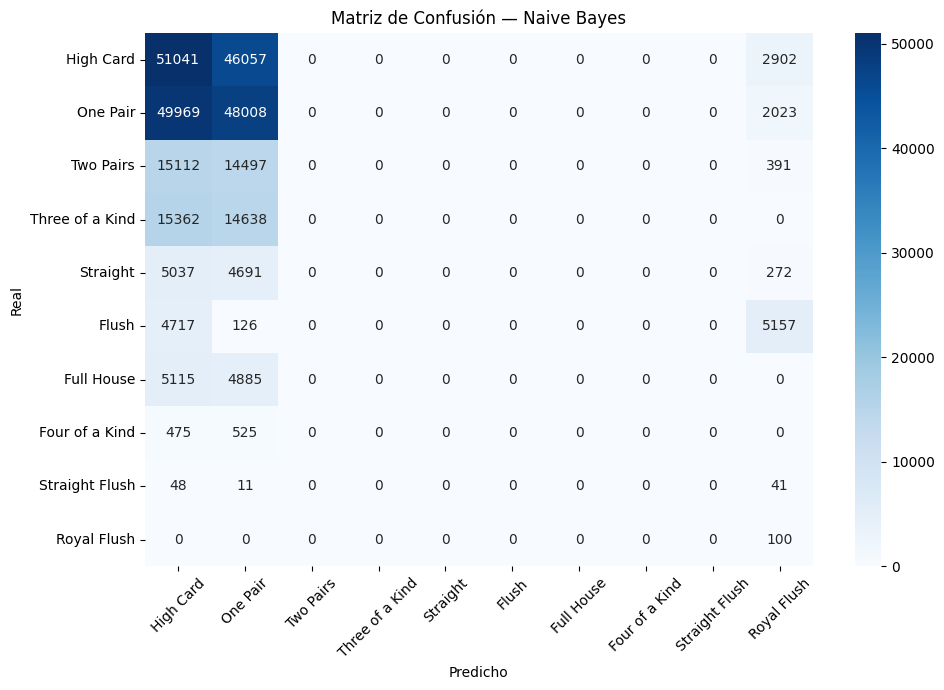

In [4]:
# 1. Cargar
df = pd.read_csv('../preprocesamiento/preprocesamiento_trainning.data', header=None)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

clases = sorted(y.unique().astype(int).tolist())
clase_nombres = {
    0: "High Card", 1: "One Pair", 2: "Two Pairs", 3: "Three of a Kind",
    4: "Straight",  5: "Flush",   6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}
nombres_ordenados = [clase_nombres[c] for c in clases]

# 2. Naivebayes
modelo_nb = GaussianNB()
modelo_nb.fit(x, y)
y_pred = modelo_nb.predict(x)

# 3. Métricas
print("Métricas del modelo Naive Bayes:")
print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
print(f"Recall   : {recall_score(y, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1       : {f1_score(y, y_pred, average='macro', zero_division=0):.4f}")
print("Instancias procesadas:", len(y))

# 4. Matriz de confusión
cm_nb = confusion_matrix(y, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_nb, annot=True, fmt='d', cmap='Blues',
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)
plt.title("Matriz de Confusión — Naive Bayes")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()